<h1>Understanding Prolate Jellyfish Locomotion Efficiency through Numerical Simulation of Bell Kinematics.</h1>
<h3>This file is used to create the jellyfish kinematics and plot the results.</h3>

In [1]:
using LinearAlgebra, Printf, Statistics, Plots, ParametricBodies, StaticArrays
using WaterLily, CUDA
using GeometryBasics, Optim
using BiotSavartBCs
include("viz.jl");

Jellyfish kinematics from Sahin et al. (2009) that are used to acquire the control points of a jellyfish geometry for future simulations.

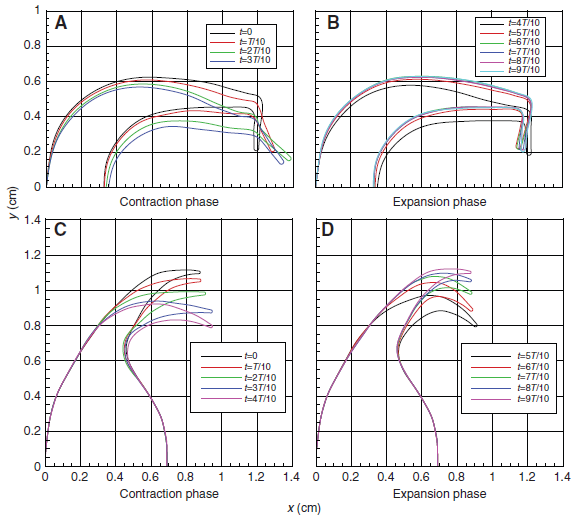

In [2]:
display("image/png", read("Sahin Jellyfish Kinematics.png"))

Definition of the control points of the moving jellyfish on each time step, derived from above pictures using the digitizer "https://automeris.io/". The coordinates are given in [cm], something that should be taken note of in the future simulations and the derived components such as velocity and acceleration. Every timestep is defined as a set of control points, which are all listed into a vector. Only half of the jellyfish is actually digitized, the other half is simply constructed by mirroring the control point sets around the x-asis. The control points are then reversed to define the shape counter-clockwise, as this is a requirement for having a flow around the body. Using clockwise control points it results in a flow inside of the body. 

In [6]:
function create_cps_list(::Type{T}) where {T<:AbstractFloat}
    # t = 0
    cps_0 = SA{T}[0.000  0.024  0.064  0.175  0.323  0.481  0.643  0.798  0.996  1.191  1.228  1.201  1.171  1.178  1.154  0.804  0.606  0.475  0.397  0.340  0.323  
                    0.000  0.193  0.333  0.475  0.578  0.623  0.627  0.614  0.571  0.524  0.484  0.213  0.216  0.412  0.456  0.451  0.420  0.348  0.266  0.151 0.000  ] #*L .+ SA{T}[2L,3L]
    # t = T/10
    cps_1 = SA{T}[0.000  0.024  0.067  0.175  0.326  0.488  0.639  0.794  0.993  1.164  1.198  1.296  1.265  1.171  1.090  0.801  0.606  0.478  0.404  0.343  0.323  
                    0.000  0.193  0.326  0.469  0.564  0.609  0.606  0.590  0.537  0.501  0.470  0.216  0.206  0.412  0.426  0.438  0.396  0.335  0.256  0.154  0.000  ] # *L .+ SA{T}[2L, 3L]
    # t = 2T/10
    cps_2 = SA{T}[0.000  0.024  0.081  0.188  0.333  0.481  0.639  0.798  0.986  1.171  1.222  1.390  1.373  1.205  1.154  0.801  0.616  0.501  0.427  0.370  0.323  
                    0.000  0.193  0.319  0.455  0.547  0.589  0.583  0.550  0.473  0.419  0.321  0.173  0.159  0.304  0.334  0.380  0.366  0.311  0.243  0.148 0.000  ] #*L .+ SA{T}[2L,3L]
    # t = 3T/10
    cps_3 = SA{T}[0.000  0.034  0.091  0.199  0.337  0.481  0.629  0.781  0.973  1.077  1.181  1.346  1.319  1.198  1.154  0.798  0.643  0.522  0.448  0.387  0.357  
                    0.000  0.193  0.322  0.448  0.541  0.568  0.566  0.533  0.449  0.412  0.392  0.149  0.135  0.291  0.301  0.343  0.342  0.287  0.226  0.141  0.000  ] # *L .+ SA{T}[2L, 3L]    
    # t = 4T/10
    cps_4 = SA{T}[0.000  0.027  0.081  0.199  0.357  0.478  0.626  0.781  0.976  1.178  1.222  1.228  1.191  1.195  1.151  0.801  0.633  0.525  0.438  0.384  0.347  
                    0.000  0.204  0.326  0.466  0.562  0.589  0.587  0.560  0.507  0.467  0.437  0.200  0.206  0.359  0.389  0.381  0.363  0.315  0.233  0.158  0.000  ] # *L .+ SA{T}[2L, 3L]
    # t = 5T/10
    cps_5 = SA{T}[0.000  0.027  0.074  0.182  0.340  0.471  0.629  0.791  0.989  1.185  1.222  1.151  1.124  1.164  1.127  0.798  0.616  0.498  0.407  0.360  0.337  
                    0.000  0.204  0.340  0.483  0.585  0.620  0.624  0.608  0.561  0.518  0.478  0.237  0.250  0.420  0.454  0.452  0.410  0.352  0.253  0.172  0.000  ] # *L .+ SA{T}[2L, 3L]
    # t = 6T/10
    cps_6 = SA{T}[0.000  0.027  0.074  0.182  0.330  0.464  0.629  0.794  0.989  1.185  1.225  1.158  1.124  1.164  1.141  0.794  0.613  0.488  0.394  0.343  0.330  
                    0.000  0.204  0.340  0.483  0.592  0.637  0.641  0.628  0.592  0.532  0.495  0.233  0.250  0.403  0.454  0.469  0.424  0.366  0.267  0.175  0.000  ] # *L .+ SA{T}[2L, 3L]
    # t = 7T/10
    cps_7 = SA{T}[0.000  0.027  0.074  0.182  0.330  0.464  0.629  0.794  0.989  1.185  1.225  1.178  1.144  1.164  1.141  0.794  0.613  0.488  0.394  0.343  0.330  
                    0.000  0.204  0.340  0.483  0.592  0.637  0.641  0.628  0.592  0.532  0.495  0.227  0.230  0.403  0.454  0.469  0.424  0.366  0.267  0.175  0.000  ] # *L .+ SA{T}[2L, 3L]
    # t = 8T/10
    cps_8 = SA{T}[0.000  0.027  0.074  0.182  0.330  0.464  0.629  0.794  0.989  1.185  1.225  1.185  1.151  1.164  1.141  0.794  0.613  0.488  0.394  0.343  0.330  
                    0.000  0.204  0.340  0.483  0.592  0.637  0.641  0.628  0.592  0.532  0.495  0.230  0.233  0.403  0.454  0.469  0.424  0.366  0.267  0.175  0.000  ] # *L .+ SA{T}[2L, 3L]
    # t = 9T/10
    cps_9 = SA{T}[0.000  0.027  0.074  0.182  0.330  0.464  0.629  0.794  0.989  1.185  1.225  1.191  1.154  1.164  1.141  0.794  0.613  0.488  0.394  0.343  0.330  
                    0.000  0.204  0.340  0.483  0.592  0.637  0.641  0.628  0.592  0.532  0.495  0.220  0.220  0.403  0.454  0.469  0.424  0.366  0.267  0.175  0.000  ] # *L .+ SA{T}[2L, 3L]
    
    cps_list = [cps_0, cps_1, cps_2, cps_3, cps_4, cps_5, cps_6, cps_7, cps_8, cps_9] #10-element (Vector{SMatrix{2, 22, Float32, 44}})

    function make_symmetric_jelly(cps_list::AbstractVector{<:SMatrix{2,N,T}};
                                        tol = nothing) where {N,T}
        tol === nothing && (tol = sqrt(eps(T)))

        first_cps = cps_list[1]::SMatrix{2,21,Float32,42}
        keep_idxs = findall(j -> abs(first_cps[2, j]) > tol, 1:N)   # length K
        K = length(keep_idxs)
        M = N + K + 1                                               # Final column count, added 1 for the 0,0 point
        keep_rev = Tuple(reverse(keep_idxs))                        # Reverse order for mirrored control points

        build_sym_jelly(cps::SMatrix{2,N,T}) where {N,T} = SMatrix{2,M,T}(
            ntuple(2M) do k
                if k <= 2N                                          # Original control points   
                    i = (k - 1) % 2 + 1
                    j = (k + 1) ÷ 2
                    cps[i, j]
                elseif k <= 2N + 2K                                 # Create the mirrored control points and add them to the original
                    kk  = k - 2N
                    i   = (kk - 1) % 2 + 1
                    jth = (kk + 1) ÷ 2
                    col = keep_rev[jth]
                    i == 1 ? cps[1, col] : -cps[2, col]
                else
                    0                                               # Add the 0,0 point, 1st data point, again at the end.
                end
            end
        )

        map(build_sym_jelly, cps_list)                                    
    end

    reverse_cps_order(cps::SMatrix{2,N,T}) where {N,T} =        # To create the counterclockwise order
        SMatrix{2,N,T}(cps[:, reverse(1:N)])                        # Make SMatrix so that my NURBS function works

    reverse_cps_list(cps_list::AbstractVector{<:SMatrix{2,N,T}}) where {N,T} =
        map(reverse_cps_order, cps_list)
    
    cps_list = make_symmetric_jelly(cps_list)                   # Vector{Matrix{Float32}}
    opt_cps_list = reverse_cps_list(cps_list)                       # Change the cps_list from clockwise to counterclockwise order
return opt_cps_list
end

cps_list = create_cps_list(Float32) ./ Float32(1.25/2)


10-element Vector{SMatrix{2, 41, Float32, 82}}:
 [0.0 0.0384 … 0.0384 0.0; 0.0 -0.3088 … 0.3088 0.0]
 [0.0 0.0384 … 0.0384 0.0; 0.0 -0.3088 … 0.3088 0.0]
 [0.0 0.0384 … 0.0384 0.0; 0.0 -0.3088 … 0.3088 0.0]
 [0.0 0.054400004 … 0.054400004 0.0; 0.0 -0.3088 … 0.3088 0.0]
 [0.0 0.0432 … 0.0432 0.0; 0.0 -0.32639998 … 0.32639998 0.0]
 [0.0 0.0432 … 0.0432 0.0; 0.0 -0.32639998 … 0.32639998 0.0]
 [0.0 0.0432 … 0.0432 0.0; 0.0 -0.32639998 … 0.32639998 0.0]
 [0.0 0.0432 … 0.0432 0.0; 0.0 -0.32639998 … 0.32639998 0.0]
 [0.0 0.0432 … 0.0432 0.0; 0.0 -0.32639998 … 0.32639998 0.0]
 [0.0 0.0432 … 0.0432 0.0; 0.0 -0.32639998 … 0.32639998 0.0]

First trial to compute velocities between control point changes.

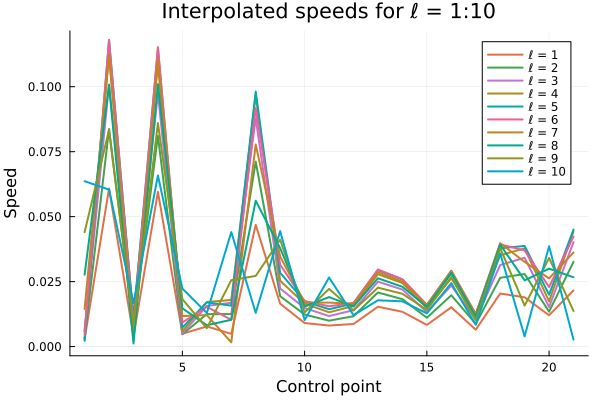

In [4]:

## Calculating the velocity of points from the tangents of frames assuming that the period T is 10 seconds, so every timestep is T/10
## I am pretty sure this can't work, as I am interpolating between frames instead of control points.
function frame_tangents(cps_list)
    N = length(cps_list)            # Number of control point sets
    # @show N
    T = similar(cps_list)
    for k in 1:N                    # Go through each frame from 1 to N
        prev = cps_list[mod(k-1, N)+1]
        # print("\n prev = ", mod(k-1, N)+1, " ")
        next = cps_list[mod(k, N)+1]
        # print("\n next = ", mod(k,   N)+1, " ")
        T[k] = 0.5 .* (next .- prev)    
        # @show T[k]
    end
    return T         
end

# 2) Hermite blend between frames k and k+1, s∈[0,1]
function hermite_blend(P0, P1, M0, M1, s)
    s2 = s*s; s3 = s2*s
    h00 =  2*s3 - 3*s2 + 1
    h10 =    s3 - 2*s2 + s
    h01 = -2*s3 + 3*s2
    h11 =    s3 -   s2
    return h00 .* P0 .+ h10 .* M0 .+ h01 .* P1 .+ h11 .* M1
end

s = 0:0.1:1

tangents = frame_tangents(cps_list)

interpolate = [Vector{Any}(undef, length(s)) for _ in 1:length(cps_list)]

for k in 1:length(cps_list)
    for j in 1:length(s)
        interpolate[k][j] = hermite_blend(
            cps_list[k],
            cps_list[mod1(k+1, length(cps_list))],
            tangents[k],
            tangents[mod1(k+1, length(cps_list))],
            s[j]
        )
    end
end
k  = 1               # frame index
ℓs = 1:10            # interpolated step index
Jx = 1:21            # x control-point indices
Jy = 22:42           # y control-point indices
Δs = s[2] - s[1]     # 0.1 step size
# println(interpolate[1][1])
interp_veloc = plot(1:21, zeros(21); label="", linewidth=0)  # placeholder to set axes
for ℓ in ℓs
    vx = [(interpolate[k][ℓ+1][j] - interpolate[k][ℓ][j]) / Δs for j in Jx]
    # println("vx = ", vx)
    vy = [(interpolate[k][ℓ+1][j] - interpolate[k][ℓ][j]) / Δs for j in Jy]
    # println("vy = ", vy)
    speeds = sqrt.((vx .^ 2) .+ (vy .^ 2))                   # 21-point speed curve
    plot!(1:21, speeds; label="ℓ = $ℓ", linewidth=2)
end

xlabel!("Control point")
ylabel!("Speed")
title!("Interpolated speeds for ℓ = 1:10")
display(interp_veloc)

Area error between the time steps, this error must be minimised in order to acquire volume conservation (now it could be said that this is 'area conservation', which is required for eventually volume conservation in 3D).

An algorithm was used for which a Julia package was available, the Optim package (documentation on https://julianlsolvers.github.io/Optim.jl/stable/user/minimization/). This uses the area error and the shape error with an operator that defines the balance between both errors. The initial array consists of the digitised control points. It defines the cost function then as: 

cost = $\epsilon_{area}^2 + \lambda \cdot \epsilon_{shape}$

It applies the Nelder-Mead method in multivariate cases. It uses the cost function, initial control points and NM method to acquire optimisation results, after which the minimizer outputs the best control points to acquire the best cost value.

Right now I calculate the area with a 'poly_area' function that uses the shoelace formula. It should be checked that this formula is actually appropriate for this case, although I cannot see why it wouldn't. 

Shape Area Summary:
────────────────────────────────────────────
Curve t/T  Area            Δ% from t = 0  
────────────────────────────────────────────
Curve 1     1.603470        0.00           
Curve 2     1.603344        -0.01          
Curve 3     1.603382        -0.01          
Curve 4     1.603583        0.01           
Curve 5     1.603303        -0.01          
Curve 6     1.603466        -0.00          
Curve 7     1.603412        -0.00          
Curve 8     1.603605        0.01           
Curve 9     1.603433        -0.00          
Curve 10    1.603471        0.00           


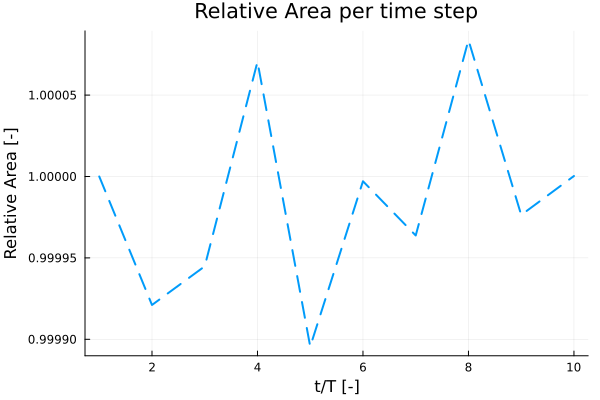

In [7]:
function poly_area(points::Vector{SVector{2,T}}) where T # Polygon area using the shoelace formula
    n = length(points)
    sum = zero(T)
    for i in 1:n
        x1, y1 = points[i]
        x2, y2 = points[mod1(i+1, n)]
        sum += x1 * y2 - x2 * y1
    end
    area = abs(sum) / 2
    return area
end

## Initialize the B-spline curves and calculate areas
function optimize_control_points(cps::SMatrix{2,N,T}, reference_area; λ::T = T(1e-3), degree::Int = 2, nsamples::Int = 500) where {N,T}

    # mutable initial vector for Optim
    cps_0 = vec(Array{Float32}(cps))           # 2N-vector
    values = range(0, stop=1, length=nsamples)

    cost = function (x::AbstractVector)
        # reshape 2N -> 2×N
        X = reshape(x, 2, N)

        cps_new = SMatrix{2,N,Float32}(Tuple(vec(X))...)  # same size as cps

        curve = BSplineCurve(cps_new; degree=degree)
        pts = (curve(s) for s in values)
        area = poly_area(collect(pts))

        area_error  = area - reference_area
        shape_error = sum(abs2, x .- cps_0)                  # keep close to original cps

        return area_error^2 + λ * shape_error
    end

    result = optimize(cost, copy(cps_0), NelderMead())
    cps_opt = Optim.minimizer(result)
    cps_opt = reshape(cps_opt, 2, N)

    return SMatrix{2,N,Float32}(Tuple(vec(cps_opt))...)
end

values = range(0, stop=1, length=500)
ref_curve = BSplineCurve(cps_list[1]; degree=2)  # Reference curve for area comparison
ref_points = [ref_curve(s) for s in values]  # Evaluate the reference curve at the sampled points
ref_area = poly_area(ref_points)  # Calculate the area of the reference polygon
opt_cps_list = [optimize_control_points(cps, ref_area) for cps in cps_list]
opt_cps_list = Vector{SMatrix{2,41,Float32,82}}(opt_cps_list)

cps_curves = [BSplineCurve(cps; degree=2) for cps in opt_cps_list]      # Create a list of B-spline curves from control points
cps_points = [[curve(s) for s in values] for curve in cps_curves]       # # Evaluate each curve at the sampled points
cps_areas = [poly_area(pts) for pts in cps_points]              # Calculate the area of each polygon defined by the points

rel_area = [area / ref_area for area in cps_areas]
rel_errors = [(area - ref_area) / ref_area * 100 for area in cps_areas]

println("Shape Area Summary:")
println("────────────────────────────────────────────")
@printf("%-10s %-15s %-15s\n", "Curve t/T", "Area", "Δ% from t = 0")
println("────────────────────────────────────────────")
for i in 1:length(cps_areas)
    @printf("Curve %-4d  %-15.6f %-15.2f\n", i, cps_areas[i], rel_errors[i])
end

# plot(1:length(areas), areas; label="Area", xlabel="t/T", ylabel="Area", linewidth=2, legend=:topleft, title="Area per time step")
plot(1:length(rel_area), rel_area; label="Relative Area [-]", xlabel="t/T [-]", ylabel="Relative Area [-]",  linewidth=2, legend=:false, linestyle=:dash, title="Relative Area per time step")

<h4>Static plots of the different time steps during jellyfish motion.</h4>
The poly_area function can compute the area of each control point set by applying the shoelace formula. This formula uses the coordinates of two vertices to derive the area 'in between' those points. It can be applied to a counter clockwise set of 'vertices'. In this case, a set of points is defined for vortice input in between each control point. A total of 500 points along the curve are defined and used as input to acquire the area with the poly_area formula. 

Using the defined curves, which are a result of the control point sets, plots are made of each 'time step' of the jellyfish motion. It is defined as a function of the actual motion period of the jellyfish. The areas are also computed and the area difference in percentages is given as well. 

To do: Improve the plots.

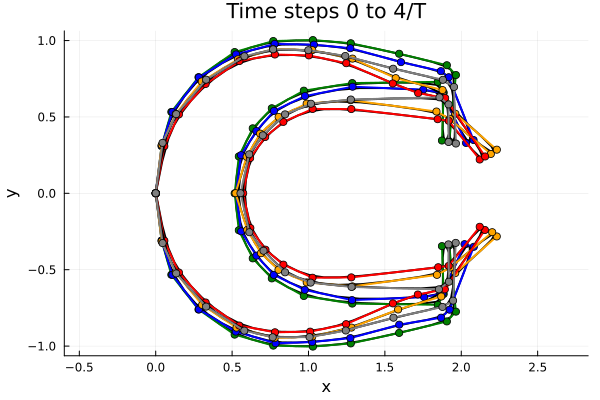

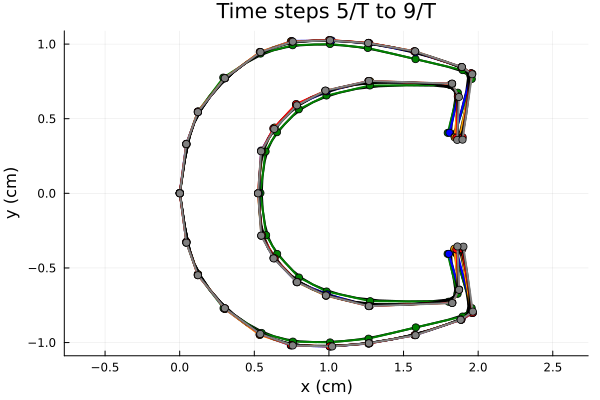

In [8]:
function plot_shapes(cps_list::AbstractVector{<:SMatrix{2,N,T}}, curves) where {N,T}  # Plot the shapes and calculate area differences (actually only percentage difference between set 2 and set 1)
    
    plt0_4 = plot(curves[1]; label="0", aspect_ratio=:equal, linewidth=2, color=:green)
    plot!(plt0_4, curves[2]; label="1/T", linewidth=2, color=:blue)
    plot!(plt0_4, curves[3]; label="2/T", linewidth=2, color=:orange)
    plot!(plt0_4, curves[4]; label="3/T", linewidth=2, color=:red)
    plot!(plt0_4, curves[5]; label="4/T", linewidth=2, color=:grey,
        xlabel="x", ylabel="y", title="Time steps 0 to 4/T", legend=:true)
    
    labels = ["5/T", "6/T", "7/T", "8/T", "9/T"]
    plt5_9 = plot(curves[6]; aspect_ratio=:equal, linewidth=2, color=:green, legend=:true)
    plot!(plt5_9, curves[7]; linewidth=2, color=:blue)
    plot!(plt5_9, curves[8]; linewidth=2, color=:orange)
    plot!(plt5_9, curves[9]; linewidth=2, color=:red)
    plot!(plt5_9, curves[10]; linewidth=2, color=:grey,
        xlabel="x (cm)", ylabel="y (cm)", title="Time steps 5/T to 9/T")

    display(plt0_4)
    display(plt5_9)
end

plot_shapes(opt_cps_list, cps_curves)

Below is a code that calculates the area of the cavity volume, using the control points on the 'inside' of the jellyfish. For now, this is a rather questionable method because of the following reasons: 
- Is the formula $V_{cavity} = A_{cavity} \cdot 2 \pi c_{cavity}$ where $c_{cavity}$ is the average centroid of the cavity. 
- When the 'flap' extends outside of the initial jellyfish shape, that area part is also added, which would significantly increase the cavity volume. Perhaps a virtual line should be drawn for the initial jelly shape to correctly use the cavity volume as a comparison metric across time steps.


centroids = Any[0.30222222f0, 0.2913377f0, 0.24999925f0, 0.23198372f0, 0.26978314f0, 0.30789164f0, 0.31442156f0, 0.3124556f0, 0.31269085f0, 0.31127954f0]
areas_aperture = [0.6762774191403447, 0.6906736710792701, 0.6383901977679383, 0.554700227601806, 0.5769070303498195, 0.6268532999994064, 0.6605014695553867, 0.6753032226436374, 0.6812218676325879, 0.6838497088079887]


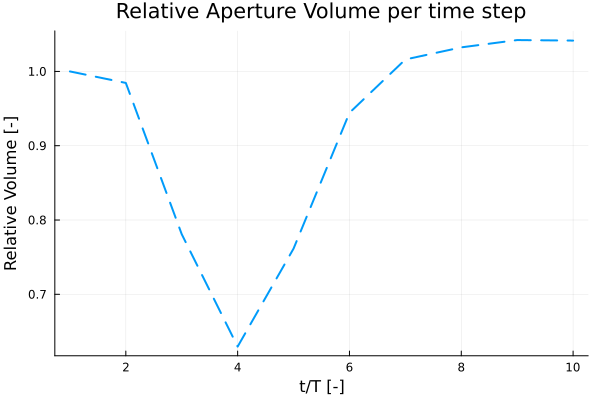

In [ ]:
function get_inside_cps(cps_list::Vector{SMatrix{2,N,T,82}}) where {N,T}
    inside_cps = Vector{SMatrix{2,18,T}}()
    centroids = []  # Store centroids for each set
    for cps in cps_list
        insides = hcat(cps[:,13:29],cps[:,13])      # added cps13 again to close the area
        cps_centroids = cps[2,13:21]                     # y-coordinates only for centroid calculation
        centroid = abs(sum(cps_centroids)) / length(cps_centroids)  
        push!(centroids, centroid)  # Store the centroid for this set
        push!(inside_cps, insides)
    end
    return inside_cps, centroids
end

inside_cps, centroids = get_inside_cps(opt_cps_list)  # Get the specific control points for the inside of the jellyfish
@show centroids
curves_aperture = [BSplineCurve(cps; degree=2) for cps in inside_cps]
points_aperture = [[curve(s) for s in values] for curve in curves_aperture]
areas_aperture = [poly_area(pts) for pts in points_aperture]
@show areas_aperture
volumes_aperture = areas_aperture .* centroids .* 2π    # Is this correct? I think so, but I am not sure.
volumes_aperture = volumes_aperture ./ volumes_aperture[1]  # Normalize the volumes to the first volume

plot(1:length(volumes_aperture), volumes_aperture; label="Relative Aperture Volume [-]", xlabel="t/T [-]", ylabel="Relative Volume [-]",  linewidth=2, legend=:false, linestyle=:dash, title="Relative Aperture Volume per time step")


Gif of the dynamically moving shape.

In [8]:
# display(cps_list)

# function animate_cps_direct(opt_cps_list;loops=4, fps=10)
#     degree = 2
#     gen_motion = @gif for _ in 1:loops, (i, cps) in enumerate(opt_cps_list)
#         curve = BSplineCurve(cps; degree=degree)
#         s_vals = range(0, stop=1, length=300)
#         pts = [curve(s) for s in s_vals]
#         area = poly_area(pts)
#         plt = plot(curve; aspect_ratio=:equal, label="", linewidth=2,
#                    xlabel="x", ylabel="y",
#                    title="t/T = $(i-1)/$(length(cps_list)-1), Area = $(round(area, digits=4))")
#         plot!(plt, legend=false)
#     end every 1 fps=fps
#     display(gen_motion)
# end


@inline function interpolate_cps_gif(opt_cps_list, t, Δt; nphases::Int=10)    
    period = Float32(10)
    τ_total = t / period
    k = floor(Int, τ_total * nphases)
    τ_local = τ_total * nphases - k

    cps_a = opt_cps_list[mod(k, nphases) + 1]
    cps_b = opt_cps_list[mod(k+1, nphases) + 1]

    interpolated = ((Tp(1) - τ_local) .* cps_a .+ τ_local .* cps_b)

    return interpolated
end

function animate_cps_interpolated(opt_cps_list; loops=1, fps=10, Δt=0.01)
    degree = 2
    times = Float32(0):Float32(Δt):Float32(10)  # total duration is assumed to be 10 units

    gen_motion = @gif for _ in 1:loops, t in times
        cps = interpolate_cps_gif(opt_cps_list, t, Δt)
        curve = BSplineCurve(cps; degree=degree)
        s_vals = range(0, stop=1, length=300)
        pts = [curve(s) for s in s_vals]
        area = poly_area(pts)

        plt = plot(curve; aspect_ratio=:equal, label="", linewidth=2,
                   xlabel="x", ylabel="y",
                   title="Interpolated t=$(round(t; digits=2)), Area=$(round(area; digits=4))")
        plot!(plt, legend=false)
    end every 1 fps=fps

    display(gen_motion)
end

animate_cps_interpolated(opt_cps_list)

UndefVarError: UndefVarError: `Tp` not defined

Static shape testing with both a circle and the jellyfish first set of control points.

In [9]:
# ## Static shape testing.
# function circle(;L=2^3,Re=250,U=1,mem=Array,T=Float32)              # Trial, why does a circle work?
#     # NURBS points, weights and knot vector for a circle
#     cps = SA_F32[1 1 0 -1 -1 -1  0  1 1
#                 0 1 1  1  0 -1 -1 -1 0]*L/2 .+ [2L,3L]
#     weights = SA_F32[1.,√2/2,1.,√2/2,1.,√2/2,1.,√2/2,1.]
#     knots =   SA_F32[0,0,0,1/4,1/4,1/2,1/2,3/4,3/4,1,1,1]

#     # make a nurbs curve and a body for the simulation
#     Body = ParametricBody(NurbsCurve(cps,knots,weights))
#     Simulation((8L,6L),(U,0),L;U,ν=U*L/Re,body=Body,T=T,mem=mem)
# end

# ### Testing 1 cps set.
# function clamped_uniform_knots(p::Int, n::Int)
#     k = zeros(Float64, n + p + 1)
#     k[p+1:end-p] .= range(0, 1, length=n - p + 1)
#     k[end-p+1:end] .= 1.0
#     return k
# end

# function Jellyfish(;L=2^3,Re=250,U=1,ϵ=0.5,mem=Array,T=Float32)
#     cps = SA{T}[0.0 0.024 0.064 0.175 0.323 0.481 0.643 0.798 0.996 1.191 1.228 1.201 1.171 1.178 1.154 0.804 0.606 0.475 0.397 0.34 0.323 0.34 0.397 0.475 0.606 0.804 1.154 1.178 1.171 1.201 1.228 1.191 0.996 0.798 0.643 0.481 0.323 0.175 0.064 0.024 0.0;
#      0.0 -0.193 -0.333 -0.475 -0.578 -0.623 -0.627 -0.614 -0.571 -0.524 -0.484 -0.213 -0.216 -0.412 -0.456 -0.451 -0.42 -0.348 -0.266 -0.151 0.0 0.151 0.266 0.348 0.42 0.451 0.456 0.412 0.216 0.213 0.484 0.524 0.571 0.614 0.627 0.623 0.578 0.475 0.333 0.193 0.0]*L .+ SA{T}[2L,3L]
#     degree = 2
#     n_ctrl = size(cps, 2)
#     weights = ones(T, n_ctrl)
#     knots = T.(clamped_uniform_knots(degree, n_ctrl))
#     println("cps = ", cps_list[1])
#     println("knots = ", knots)
#     println("weights = ", weights)
#     curve = NurbsCurve(cps, knots, weights)         
#     body = DynamicNurbsBody(curve; thk=3ϵ+√3, boundary=true)

#     Simulation((8L,6L),(U,0),L; U, ν=U*L/Re, body, T, mem,ϵ)
# end

# sim = Jellyfish(mem=Array);
# t₀, duration, tstep = sim_time(sim), 10, 0.1;

# Tp = eltype(sim.flow.p)

# # run
# @gif for tᵢ in range(t₀,t₀+duration;step=tstep)
#     # update until time tᵢ in the background
#     sim_step!(sim,tᵢ)
#     # flood plot
#     get_omega!(sim);
#     plot_vorticity(sim.flow.σ, limit=10)
#     plot!(sim.body.curve;shift=(1.5,1.5),add_cp=false)

#     println("tU/L=",round(tᵢ,digits=4),", Δt=",round(sim.flow.Δt[end],digits=3))
# end

Below are several functions given that are used to setup a simulation of a moving jellyfish. The first function is to derive centroid values from the control points to compute the jellyfish area and cavity volume during simulation. Then a function is defined to setup an array representing the knots that are used to define the NURBS which determines where and how control points affect the NURBS curve. Next a function is defined that can compute the area of the jellyfish using the earlier defined poly_area function, which uses the shoelace formula to compute the area. 

The function 'dynamicSpline' is the simulation setup function. It defines the starting geometry of the jellyfish from the first set of control points in the list. This is scaled with the scaling length L. It creates an array of weights for the control points with all control points having equal weight. The knots array is computed in this function and together with the control points a NURBS curve is created. Viscosity is computed from the defined length and velocity scale, respectively L and U, and the Reynolds number, which is also manually inputted. The optionality is added to apply biotsavart boundary conditions in the simulation by setting this option to true. 

What exactly is biotsavart?

The function 'interpolate_cps' is used to interpolate between the different control point sets, to make sure that motion steps are not too large. A very general interpolation is used through creating a time scale and using the 2 control point sets in between interpolation is conducted. It was aimed to include Newtons 2nd law in order to compute the acceleration. The goal is to use this acceleration to compute velocity and position change of the jellyfish resulting from the generated flow momentum. The pressure force is used as the reference force in $F = V \cdot a$. Note that the volume is used instead of mass, as F is computed as $\frac{p}{\rho}$ and $V = \frac{m}{\rho}$. 

In [39]:
function get_centroid(cps::SMatrix{2,41,T}) where {N,T}
    idx = SMatrix{2,18,T}(hcat(cps[:,13:29],cps[:,13]))
    idx2 = cps[2,13:21]
    centroid = Float32(abs(sum(idx2)) / length(idx2))  
    return idx, centroid
end

function clamped_uniform_knots(p::Int, n::Int)
    k = zeros(Float64, n + p + 1)
    k[p+1:end-p] .= range(0, 1, length=n - p + 1)
    k[end-p+1:end] .= 1.0
    return k
end

function get_area(cps)                          
    curve = BSplineCurve(cps; degree=2)
    points = [curve(s) for s in s_vals]
    area = poly_area(points)
    return area
end

@inline function MovingJelly(::Type{T}=Float32; opt_cps_list,L=2^5,Re=302,U=1,ϵ=0.5,thk=2ϵ+√3,mem=Array, use_biotsavart=false) where {T<:AbstractFloat}
    cps = opt_cps_list[1] .* L .+ SA{T}[L/2,3L/2]
    degree = 2
    n_ctrl = size(cps, 2)
    weights = ones(T, n_ctrl)
    knots = T.(clamped_uniform_knots(degree, n_ctrl))

    curve = NurbsCurve(cps, knots, weights)         

    body = DynamicNurbsBody(curve; thk=thk, boundary=true)
    ν = U*L/Re
    return use_biotsavart ?
    BiotSimulation((4L,3L),(0,0),L; U, ν, body, T, mem, ϵ) :
    Simulation((4L,3L),(0,0),L; U, ν, body, T, mem,ϵ, 
    # exitBC=true
    )
end

include("viz.jl");
sim = MovingJelly(; opt_cps_list, mem=CuArray, use_biotsavart=true);
Tp = eltype(sim.flow.p)
@show typeof(sim)

@inline function interpolate_cps(opt_cps_list, t::Tp, Δt::Tp, sim, v::Tp, s::Tp; nphases::Int=10)    
    period = Tp(1) * sim.L / sim.U
    τ_total = t / period
    k = floor(Int, τ_total * nphases)
    τ_local = τ_total * nphases - k

    cps_a = opt_cps_list[mod(k, nphases) + 1]
    cps_b = opt_cps_list[mod(k+1, nphases) + 1]

    # force = WaterLily.pressure_force(sim)[1]
    # @show WaterLily.pressure_force(sim)[1]
    # volume = (get_area(cps_a) * Tp(2) * π * maximum(cps_a[2,:]))
    # @show volume

    # a = force / (volume*sim.L^3)
    # @show a
    # v::Tp = v + a * Δt
    # s::Tp += s + v * Δt 
    # @show s
    offset = SVector{2, Tp}(sim.L/2, 3sim.L/2)
    # interpolated = ((Tp(1) - τ_local) .* cps_a .+ τ_local .* cps_b) .* sim.L .+ offset
    interpolated = cps_a .* sim.L .+ offset
    # @show interpolated
    return interpolated
end


typeof(sim) = BiotSimulation


interpolate_cps (generic function with 1 method)

The WaterLily total force is the net hydrodynamic force on the body, the surface integral of pressure and viscous shear over the body. This is a global vector. So if it is positive, it would result in a force forward, if its negative, it would result in a net force backward. This would mean that with this fluctuating total force the jellyfish moves forward and then backwards and so on. This seems somewhat logical as it is moving in place at the moment.

The following function can be used to derive the hydrodynamic forces from the WaterLily.jl simulation. It plots the force coefficients against a timescale. The input is a non-dimensional time(step) range $t_i$. The function returns the forces for each timestep defined and saves it in an array for plotting. The variable t is updated with the numerical timestep $\Delta t$. This continues until the final value $t_i \frac{L}{U}$ is reached. $\frac{L}{U}$ is the timescale to make the input time dimensional. I have some questions on this time scaling and whether I am interpeting this right.

The get_forces! function returns the pressure, viscous or total force (depending on setting) from WaterLily. The 'force' outputted by WaterLily is dimensionalised as $\frac{p}{\rho}$ and then scaled into a force coefficient as $\frac{Force}{0.5LU^2}$. 

In [ ]:
function get_forces!(sim, tᵢ)
    Tp = eltype(sim.flow.p)

    # current solver time (use whatever you consider the ground truth; or track it yourself)
    t = sum(sim.flow.Δt)  # note: includes last step; adjust if you meant [1:end-1]

    ts  = Tp[]           # time history
    dts = Tp[]           # Δt history
    f_hist = Vector{SVector{2,Tp}}()  # (Fx,Fy) per step, optional

    last_force = nothing
    t_target = Tp(tᵢ) * sim.L / sim.U

    while t < t_target
        Δt = sim.flow.Δt[end]

        push!(ts,  t)
        push!(dts, Δt)

        # update geometry
        interpolated = interpolate_cps(opt_cps_list, t, Δt, sim, v, s)
        interpolated = SMatrix{2,41,Float32,82}(interpolated)
        sim.sim.body = ParametricBodies.update!(sim.sim.body, interpolated, Δt)

        # advance one step (do NOT pass tᵢ each iteration; step once)
        sim_step!(sim; remeasure=true)

        raw    = WaterLily.total_force(sim)
        scaled = raw ./ (0.5 * sim.L * sim.U^2)
        last_force = scaled
        push!(f_hist, scaled)

        t += Δt
    end

    if last_force === nothing
        raw = WaterLily.total_force(sim)
        last_force = raw ./ (0.5 * sim.L * sim.U^2)
    end

    # Return histories (and the last force if you need it)
    return (force_last = last_force, ts = ts, dts = dts, forces = f_hist)
end

time = 0:0.01:10
t_final = last(time)

res = get_forces!(sim, t_final)

plot(res.ts, res.dts; label="Δt", xlabel="t", ylabel="Δt")

# println("Forces Summary:")
# println("────────────────────────────────────────────")
# @printf("%-10s %-15s %-15s\n", "time", "Force X", "Force Y")
# println("────────────────────────────────────────────")

# # Prefer iterating over paired time and force values
# for (ti, f) in zip(time, forces)
#     # Access components explicitly; works for tuples, SVectors, and Arrays
#     fx = f[1]
#     fy = f[2]
#     @printf("%-10.3f %-15.6f %-15.6f\n", ti, fx, fy)
# end

t=0.0, Δt=0.25
t=4.025, Δt=1.888
t=6.6775, Δt=0.382
t=9.7251, Δt=0.222
t=12.9112, Δt=0.269
t=16.1963, Δt=0.274
t=19.3459, Δt=0.411
t=22.575, Δt=0.564
t=25.7957, Δt=0.664
t=29.3275, Δt=0.717
t=32.0584, Δt=0.671
t=35.3888, Δt=0.665
t=38.582, Δt=0.506
t=41.6879, Δt=0.2
t=44.9597, Δt=0.307
t=48.1638, Δt=0.263
t=51.3663, Δt=0.367
t=54.7037, Δt=0.371
t=57.8398, Δt=0.395
t=60.802, Δt=0.428
t=64.4261, Δt=0.457
t=67.2016, Δt=0.464
t=70.5926, Δt=0.488
t=73.72, Δt=0.203
t=76.8316, Δt=0.264
t=80.3209, Δt=0.322
t=83.3732, Δt=0.455
t=86.8244, Δt=0.499
t=89.9226, Δt=0.52
t=93.2734, Δt=0.566
t=96.1956, Δt=0.589
t=99.2149, Δt=0.608
t=102.8878, Δt=0.613
t=105.7077, Δt=0.221
t=108.8641, Δt=0.326
t=112.1338, Δt=0.294
t=115.5934, Δt=0.396
t=118.7662, Δt=0.555
t=121.7653, Δt=0.611
t=125.0998, Δt=0.681
t=128.5594, Δt=0.695
t=131.8179, Δt=0.641
t=134.547, Δt=0.261
t=137.7393, Δt=0.209
t=140.9422, Δt=0.23
t=144.0352, Δt=0.286
t=147.2294, Δt=0.323
t=150.7107, Δt=0.451
t=153.655, Δt=0.499
t=156.8668, Δt=0.543
t=

┌ Info: Saved animation to C:\Users\evanv\AppData\Local\Temp\jl_BIVydiFwHm.gif
└ @ Plots C:\Users\evanv\.julia\packages\Plots\FFuQi\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\evanv\\AppData\\Local\\Temp\\jl_BIVydiFwHm.gif")
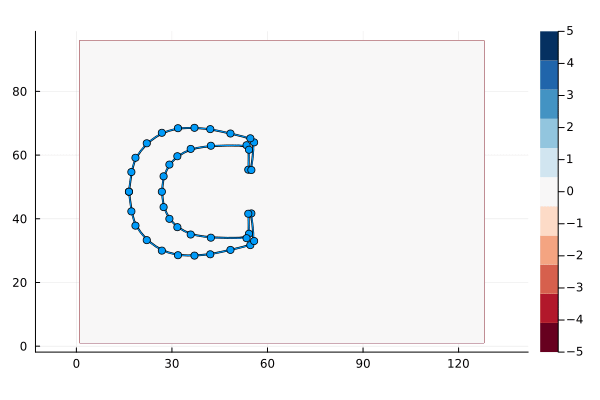

In [17]:
function get_body!(bod,sim,t=WaterLily.time(sim))
    @inside sim.flow.σ[I] = WaterLily.sdf(sim.body,SVector(Tuple(I).-0.5f0),t)
    copyto!(bod,sim.flow.σ[inside(sim.flow.σ)])
end

addbody(x,y;c=:black) = Plots.plot!(Shape(x,y), c=c, legend=false)
function body_plot!(sim;levels=[0],lines=:black,R=inside(sim.flow.p))
    WaterLily.measure_sdf!(sim.flow.σ,sim.body,WaterLily.time(sim))
    # contour!(sim.flow.σ[R]'|>Array;levels,lines)
    plot!(sim.body.curve, shift=(0.5, 0.5), add_cp=true)
end

function sim_gif!(sim;duration=1,step=0.1,verbose=true,R=inside(sim.flow.p),
                  remeasure=false,plotbody=false,kv...)
    t₀ = round(sim_time(sim))
    # @show t₀
    # t₀ = 0
    t = sum(sim.flow.Δt[1:end-1])
    v = Float32(0); s = Float32(0)
    @time @gif for tᵢ in range(t₀,t₀+duration;step)
        while t < tᵢ * sim.L / sim.U
            Δt = sim.flow.Δt[end]
            interpolated = interpolate_cps(opt_cps_list, t, Δt, sim, v, s)
            # interpolated = SMatrix{2,41,Float32,82}(interpolated)
            # sim.sim.body = ParametricBodies.update!(sim.sim.body, interpolated, Δt)

            sim.sim.body = ParametricBodies.update!(sim.sim.body, interpolated, Δt)
            sim_step!(sim,tᵢ;remeasure)
            t += Δt
        end
        @inside sim.flow.σ[I] = WaterLily.curl(3,I,sim.flow.u)*sim.L/sim.U
        @inside sim.flow.σ[I] = ifelse(abs(sim.flow.σ[I])<0.001,0.0,sim.flow.σ[I])
        flood(sim.flow.σ[R]|>Array; clims=(-5,5), kv...)
        plotbody && body_plot!(sim)
        verbose && println("t=",round(t,digits=4),
                           ", Δt=",round(sim.flow.Δt[end],digits=3))
    end
end

sim_gif!(sim; duration = 30, step = 0.1, remeasure = true, plotbody = true)         # Has no update! command in it right now.


In [ ]:
# plot(ts, geom_areas ./ reference_area; label="Relative Area [-]", xlabel="t [-]", ylabel="Relative Area [-]",  linewidth=2, legend=:false, linestyle=:dash, title="Relative Area during Simulation")
plot(ts, volumes ./ volumes[1]; label="Relative Aperture Volume [-]", xlabel="t [-]", ylabel="Relative Volume [-]",  linewidth=2, legend=:false, linestyle=:dash, title="Relative Aperture Volume during Simulation")
# plot(ts, aper_areas ./ aper_areas[1]; label="Relative Aperture Area [-]", xlabel="t [-]", ylabel="Relative Aperture Area [-]",  linewidth=2, legend=:false, linestyle=:dash, title="Relative Aperture Area during Simulation")


In [ ]:
plot(ts[2:end], pforce[2:end] ./ sim.L; label="Pressure", xlabel="t [-]", ylabel="Force [-]",  linewidth=2, legend=:true, linestyle=:dash, title="Force during Simulation")
plot!(ts[2:end], vforce[2:end] ./ sim.L; label="Viscous")

'Working' code, slow but steady

In [ ]:
function get_centroid(cps::SMatrix{2,N,T}) where {N,T}
    idx = SMatrix{2,18,T}(hcat(cps[:,13:29],cps[:,13]))
    idx2 = cps[2,13:21]
    centroid = Float32(abs(sum(idx2)) / length(idx2))  
    return idx, centroid
end

function clamped_uniform_knots(p::Int, n::Int)
    k = zeros(Float64, n + p + 1)
    k[p+1:end-p] .= range(0, 1, length=n - p + 1)
    k[end-p+1:end] .= 1.0
    return k
end

function dynamicSpline(;L=2^4,Re=500,U=1,ϵ=0.5,thk=2ϵ+√3,mem=Array,T=Float32)
    cps = opt_cps_list[1]*L .+ SA{T}[L,3L/2]
    degree = 2
    n_ctrl = size(cps, 2)
    weights = ones(T, n_ctrl)
    knots = T.(clamped_uniform_knots(degree, n_ctrl))

    curve = NurbsCurve(cps, knots, weights)         

    body = DynamicNurbsBody(curve; thk=thk, boundary=true)
    Simulation((4L,3L),(0,0),L; U, ν=U*L/Re, body, T, mem,ϵ, exitBC=true)
end

sim = dynamicSpline(mem=CuArray);
t₀, duration, tstep = sim_time(sim), 20, 0.1;

Tp = eltype(sim.flow.p)

ts = Float32[]
geom_areas = Float32[]
aper_areas = Float32[]
volumes = Float32[]

# storage
pforce,vforce,pmom = [],[],[]

function get_area(cps)
    s_vals = range(0, stop=1, length=500)                          
    curve = BSplineCurve(cps; degree=2)
    points = [curve(s) for s in s_vals]
    area = poly_area(points)
    return area
end

sim_motion = @gif for tᵢ in range(t₀, t₀ + duration; step=tstep)
    t = sum(sim.flow.Δt[1:end-1])
    period = 4 * sim.L / sim.U
    while t < tᵢ * sim.L / sim.U
        τ_total = Tp(t / period)
        frame = floor(Int, τ_total * 10)
        τ_local = τ_total * 10 - frame
        # println("frame", round(frame,digits=4))
        cps_a = opt_cps_list[mod(frame, 10) + 1]
        cps_b = opt_cps_list[mod(frame+1, 10) + 1]
        fwd_dpl = -0.02*t
        offset = SA{Tp}[sim.L + fwd_dpl, 3sim.L/2]
        interpolated = ((1 - τ_local) .* cps_a .+ τ_local .* cps_b)*sim.L .+ offset
        specific_cps, centroid = get_centroid(interpolated ./ sim.L)  # Get the specific control points for the inside of the jellyfish
        aper_area = get_area(specific_cps)  # Get the area of the specific control points
        int_area = get_area(interpolated ./ sim.L)  # Calculate the area of the interpolated polygon
        # int_range = range(0, stop=1, length=500)                           # Sample points 
        # int_curve = BSplineCurve(interpolated ./sim.L; degree=2)  # Reference curve for area comparison
        # int_points = [int_curve(s) for s in s_vals]  # Evaluate the reference curve at the sampled points
        # int_area = poly_area(int_points)  # Calculate the area of the reference polygon
        sim.body = update!(sim.body, interpolated, sim.flow.Δt[end])    #This updates the body from sim.body to interpolated, it uses Δt to update velocity
        sim_step!(sim; remeasure=true)
        sim.body
        t += sim.flow.Δt[end]
        push!(ts,t)
        push!(geom_areas, int_area)
        push!(aper_areas, aper_area)
        push!(volumes, aper_area * centroid * 2π)
        # compute and store force
        push!(pforce,WaterLily.pressure_force(sim)[1])
        push!(vforce,WaterLily.viscous_force(sim)[1])
    end

    @inside sim.flow.σ[I] = WaterLily.curl(3,I,sim.flow.u) * sim.L / sim.U
    σ = Array(sim.flow.σ)                    # still contains ghost cells
    σi = @view σ[2:end-1, 2:end-1]          # inside domain only

    ux = Array(sim.flow.u[:,:,1])  # velocity in x-direction
    uy = Array(sim.flow.u[:,:,2])  # velocity in y-direction
    ux = @view ux[2:end-1, 2:end-1]  # inside domain only
    uy = @view uy[2:end-1, 2:end-1]
    u = sqrt.(ux.^2 .+ uy.^2)  # magnitude of velocity
    xs = range(0, stop=4*sim.L, length=size(σi,1))
    ys = range(0, stop=3*sim.L, length=size(σi,2))
    # xg = [x for x in xs, y in ys]
    # yg = [y for x in xs, y in ys]
    # stride = 3
    # xg_ds = xg[1:stride:end, 1:stride:end]
    # yg_ds = yg[1:stride:end, 1:stride:end]
    # ux_ds = ux[1:stride:end, 1:stride:end]
    # uy_ds = uy[1:stride:end, 1:stride:end]

    # scale_factor = 0.05
    # Plots.contourf(xs, ys, u'; dpi=300, color=palette(:RdBu_11), clims=(0,2), linewidth=0, aspect_ratio=:equal, legend=true, xlabel="xL [-]", ylabel="yL [-]",title="Flow Velocity Magnitude")
    Plots.contourf(xs, ys, σi'; dpi=300, color=palette(:RdBu_11), clims=(-5,5), linewidth=0, aspect_ratio=:equal, legend=true, xlabel="xL [-]", ylabel="yL [-]",title="Flow Vorticity Magnitude")
    # quiver!(xg_ds, yg_ds, quiver=(ux_ds, uy_ds), arrow=true, color=:black)

    plot!(sim.body.curve; shift=(0.5,0.5), add_cp=true)

    # println("tU/L=", round(tᵢ,digits=4), ", Δt=", round(sim.flow.Δt[end], digits=3))
end

display(sim_motion)

gif_path = "dynamic_spline.gif"


To do list:
1. Minimize the area difference between time steps to acquire 'area conservation'.
2. Make a GIThub repo of the code and add it as part of the JellyfishGiggles.
3. Plot flow velocity and vorticity around the jellyfish and acquire actual flow data for possible future validation.
4. Assess period of jellyfish motion and adjust the simulation accordingly.
5. Run finer grids to see how the flow is influenced.
6. Eventually, a swimming jellyfish is required. This would require the geometry to dynamically move forward. How to do this?

In [ ]:
## Cubic Hermite / Catmull–Rom interpolation to make it C¹ continuous
using WaterLily, ParametricBodies, StaticArrays, Plots, CUDA, LinearAlgebra
using GeometryBasics
include("viz.jl");

function clamped_uniform_knots(p::Int, n::Int)
    k = zeros(Float64, n + p + 1)
    k[p+1:end-p] .= range(0, 1, length=n - p + 1)
    k[end-p+1:end] .= 1.0
    return k
end

function dynamicSpline(;L=2^3,Re=50,U=1,ϵ=0.5,thk=2ϵ+√3,mem=Array,T=Float32)
    cps = SA{T}[0.000  0.024  0.064  0.175  0.323  0.481  0.643  0.798  0.996  1.191  1.228  1.201  1.171  1.178  1.154  0.804  0.606  0.475  0.397  0.340  0.323  0.000
                0.000  0.193  0.333  0.475  0.578  0.623  0.627  0.614  0.571  0.524  0.484  0.213  0.216  0.412  0.456  0.451  0.420  0.348  0.266  0.151 0.000  0.000]*L .+ SA{T}[L,3L/2]
    degree = 2
    n_ctrl = size(cps, 2)
    weights = ones(T, n_ctrl)
    knots = T.(clamped_uniform_knots(degree, n_ctrl))

    curve = NurbsCurve(cps, knots, weights)         # Does it matter if this is BsplineCurve or NurbsCurve?
    # curve = BSplineCurve(cps; degree=degree)  # use BSplineCurve like in 3D version

    # body = HashedBody(curve, (0.0, 1.0); thk=thk, boundary=true)
    body = DynamicNurbsBody(curve; thk=thk, boundary=true)
    Simulation((4L,3L),(U,0),L; U, ν=U*L/Re, body, T, mem,ϵ)
end

# 1) Precompute per-frame tangents (periodic)
function frame_tangents(cps_list)
    N = length(cps_list)            # Number of control point sets
    @show N
    T = similar(cps_list)
    for k in 1:N                    # Go through each frame from 1 to N
        prev = cps_list[mod(k-2, N)+1]
        # print("\n prev = ", mod(k-2, N)+1, " ")
        next = cps_list[mod(k, N)+1]
        # print("\n next = ", mod(k,   N)+1, " ")
        T[k] = 0.5 .* (next .- prev)        # Catmull–Rom tangents
        @show T[k]
    end
    return T
end

interpolated = hermite_blend(cps_list[k], cps_list[kp1], tangents[k], tangents[kp1], τ_hermite)

tangents = frame_tangents(cps_list)

sim = dynamicSpline(mem=CuArray);
t₀, duration, tstep = sim_time(sim), 10, 0.1;

Tp = eltype(sim.flow.p)

# at top of the file
global prev_interp = nothing
global vmax_hist = Float64[]
global kedge = Int[]

sim_motion = @gif for tᵢ in range(t₀, t₀ + duration; step=tstep)
    t = sum(sim.flow.Δt[1:end-1])
    # println("simu", round(sim.U), "t =", round(tᵢ, digits=4))
    period = 2.0 * sim.L / sim.U
    while t < tᵢ * sim.L / sim.U
        τ_total = Tp(t / period)
        frame = floor(Int, τ_total * 10)
        # println("frame", round(frame,digits=4))
        τ_hermite = τ_total * 10 - frame
        k   = mod(frame, 10) + 1
        kp1 = mod(frame+1, 10) + 1
        # println("k, kp1 = ", k, ", ", kp1)
        interpolated = hermite_blend(cps_list[k], cps_list[kp1], tangents[k], tangents[kp1], τ_hermite)
        interpolated = interpolated * sim.L .+ SA{Tp}[sim.L, 3sim.L/2]

        if prev_interp === nothing
            # first geometry sample: just initialise and move on
            global prev_interp = interpolated
        else
            dt_geo = sim.flow.Δt[end]
            dv  = interpolated .- prev_interp
            vcp = [norm(view(dv, :, j)) / dt_geo for j in 1:size(dv,2)]
            println("vcp: ", vcp)
            global vmax_hist; push!(vmax_hist, maximum(vcp))
            global kedge;     push!(kedge, frame)

            global prev_interp = interpolated
        end
        sim.body = update!(sim.body, interpolated, sim.flow.Δt[end])
        sim_step!(sim; remeasure=true)
        t += sim.flow.Δt[end]
    end

    @inside sim.flow.σ[I] = WaterLily.curl(3,I,sim.flow.u) * sim.L / sim.U
    σ = Array(sim.flow.σ)
    vmin, vmax = extrema(σ)
    # println("vmin, vmax: ", vmin, vmax)
    
    contourf(clamp.(σ, vmin, vmax)', dpi=300,
        color=palette(:RdBu_11), clims=(-150,150), linewidth=0,
        aspect_ratio=:equal, legend=true)
    plot!(sim.body.curve; 
    # shift=(0.5,0.5), 
    add_cp=false)

    println("tU/L=", round(tᵢ,digits=4), ", Δt=", round(sim.flow.Δt[end], digits=3))
end
display(sim_motion)

@show vmax_hist[1:min(end,10)]
@show kedge[1:min(end,10)]

gif_path = "dynamic_spline.gif"



